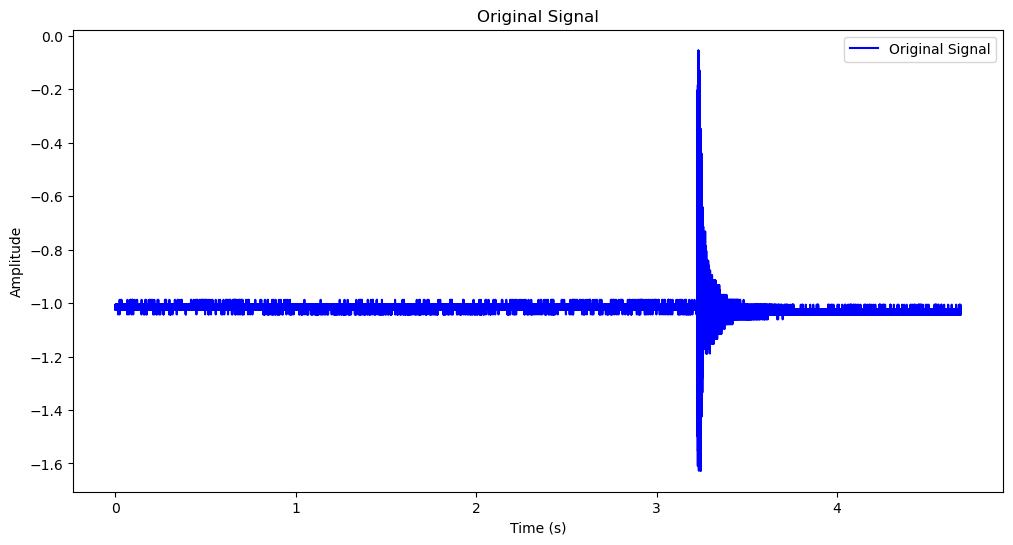

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# 1. Load dataset and slice a clean window
df = pd.read_csv('Waveforms/DATASET_02/TEST3_20_JULY_1533.csv', skiprows=[1])

# Plot the original signal
plt.figure(figsize=(12, 6))
plt.plot(df['Time'], df['Channel A'], label='Original Signal', color='blue')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Original Signal')
plt.legend()
plt.show()

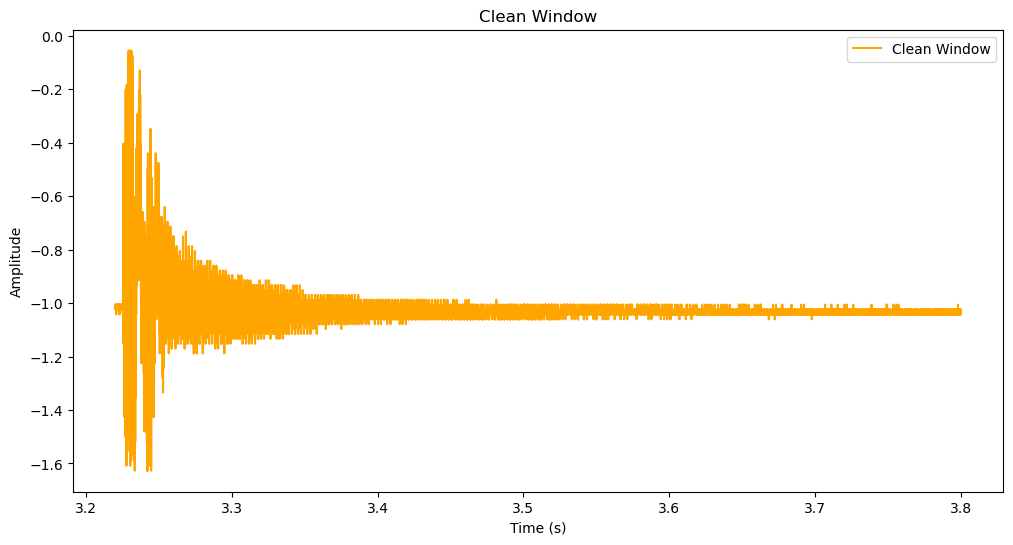

In [35]:
# Zoom into the clean window
df_slice = df[(df['Time'] >= 3.22) & (df['Time'] <= 3.8)]

plt.figure(figsize=(12, 6))
plt.plot(df_slice['Time'], df_slice['Channel A'], label='Clean Window', color='orange')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Clean Window')
plt.legend()
plt.show()

## Bandpass filter function explaination

Below piece of code handles filtering the raw signal

```python
b, a = butter(2, [200 / (fs/2), 1000 / (fs/2)], btype='band')
v_filtered = filtfilt(b, a, v_detrend)
```

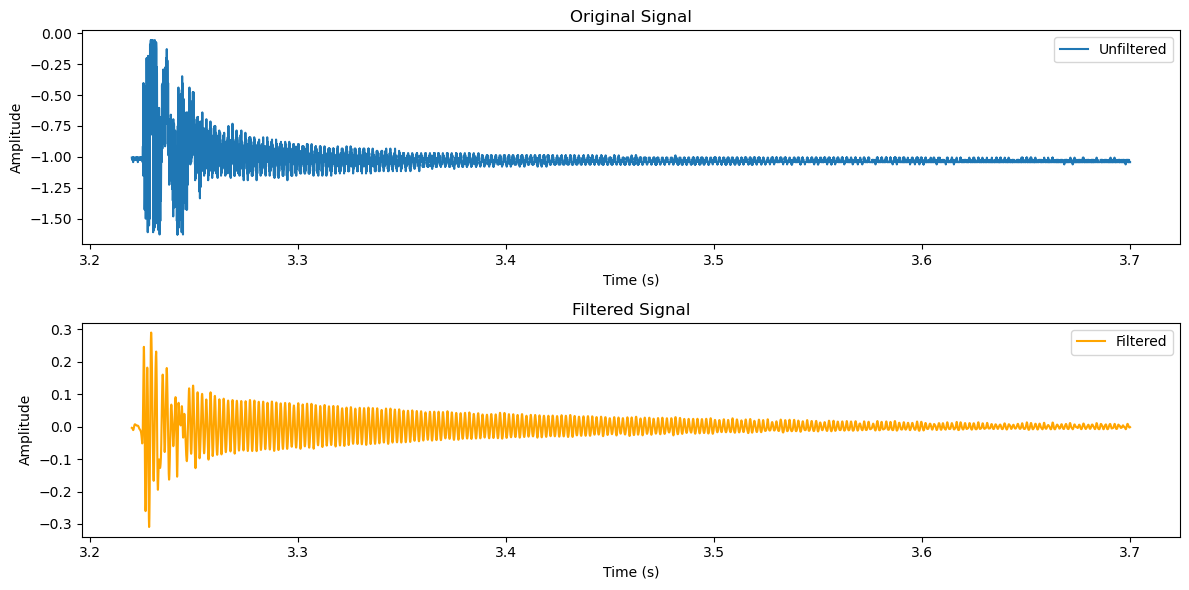

In [ ]:

df_slice = df[(df['Time'] >= 3.22) & (df['Time'] <= 3.7)].copy()

time = df_slice['Time'].values
val = df_slice['Channel A'].values

# 2. Subtract DC Baseline Offset
baseline = np.mean(df[(df['Time'] >= 0.5) & (df['Time'] <= 2.0)]['Channel A'].values)
v_detrend = val - baseline

# 3. Apply a Bandpass Filter (Removes high-frequency quantization noise)
dt = time[1] - time[0]
fs = 1.0 / dt
b, a = butter(2, [200 / (fs/2), 1000 / (fs/2)], btype='band')
v_filtered = filtfilt(b, a, v_detrend)

# Plot unfiltered and filtered signals
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(time, val, label='Unfiltered')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Original Signal')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time, v_filtered, label='Filtered', color='orange')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Filtered Signal')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
zero_crossings_idx = np.where((v_filtered[:-1] <= 0) & (v_filtered[1:] > 0))[0]

exact_zero_times = []
for idx in zero_crossings_idx:
    t1, t2 = time[idx], time[idx+1]
    v1, v2 = v_filtered[idx], v_filtered[idx+1]
    
    # Calculate slope
    m = (v2 - v1) / (t2 - t1)
    
    t0 = t1 - (v1 / m)
    exact_zero_times.append(t0)

exact_zero_times = np.array(exact_zero_times)

print("Exact Zero Crossing Times (s):", len(exact_zero_times))

Exact Zero Crossing Times (s): 226


In [26]:
periods = np.diff(exact_zero_times) # Calculate periods between consecutive zero crossings

avg_period = np.mean(periods)
f_zc = 1.0 / avg_period

print("Average Period (s):", avg_period)
print("Frequency from Zero Crossings (Hz):", f_zc)

Average Period (s): 0.002120955062429791
Frequency from Zero Crossings (Hz): 471.4857083555501


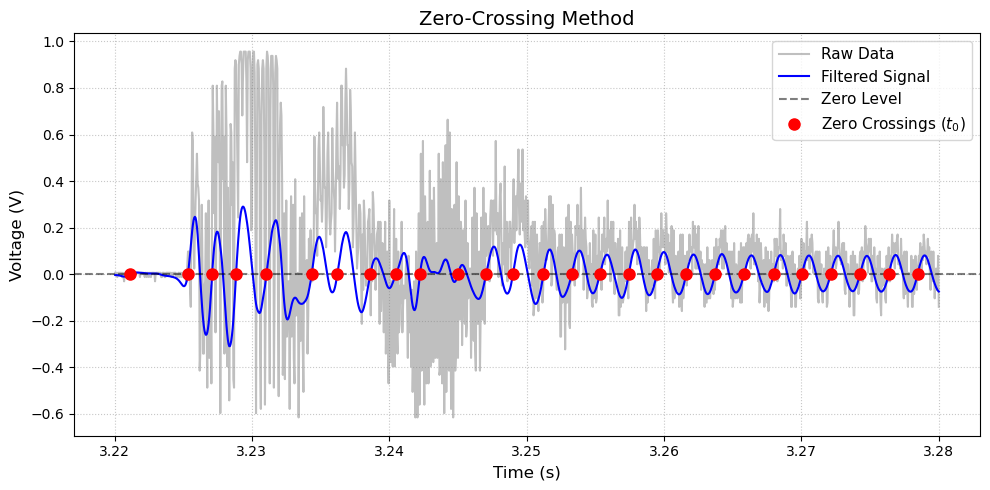

In [39]:
plt.figure(figsize=(10, 5))
plot_mask = (time >= 3.2) & (time <= 3.28)
5
plt.plot(time[plot_mask], v_detrend[plot_mask], color='gray', alpha=0.5, label='Raw Data')
plt.plot(time[plot_mask], v_filtered[plot_mask], 'b-', linewidth=1.5, label='Filtered Signal')
plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Zero Level')

# Mark exact sub-sample zero crossings
zc_plot = exact_zero_times[(exact_zero_times >= 3.2) & (exact_zero_times <= 3.28)]
plt.plot(zc_plot, np.zeros_like(zc_plot), 'ro', markersize=8, label='Zero Crossings ($t_0$)')

plt.title("Zero-Crossing Method", fontsize=14)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Voltage (V)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()